# Analyse exploratoire des données — Dataset Titanic

> **Objectif :** Analyser les données du Titanic afin d'identifier les facteurs liés à la survie des passagers, en vue de construire un modèle de classification performant.  
**Auteurs :** Nickels Ethan
---

## Table des matières

**Analyse classique**
1. [Importation des librairies](#section-1)
2. [Chargement et aperçu des données](#section-2)
3. [Statistiques descriptives](#section-3)
4. [Identification des types de variables](#section-4)
5. [Analyse des valeurs manquantes et nettoyage](#section-5)
6. [Analyse de la variable cible : survived](#section-6)
7. [Distribution du port d'embarquement](#section-7)
8. [Distribution des variables continues](#section-8)
9. [Matrice de corrélation](#section-9)
10. [Taux de survie selon le titre social](#section-10)
11. [Taux de survie selon la classe de billet](#section-11)
12. [Réfléxion originale](#section-12)

---
## 1. Importation des librairies <a id='section-1'></a>
On commence par importer les librairies nécessaires à l'analyse :
- **pandas** et **numpy** : manipulation et traitement des données tabulaires.
- **matplotlib** et **seaborn** : création de graphiques et visuel.
- **scipy.stats** : fournit des outils pour les distributions statistiques.

In [1]:
import pandas as pd
import numpy as np

# Esthétique
import seaborn as sns

# pour le plotting
import matplotlib.pyplot as plt
import seaborn as sns

# pour les transformations statistiques
import scipy.stats as stats

pd.pandas.set_option('display.max_columns', None)

---
## 2. Chargement et aperçu des données <a id='section-2'></a>
On charge le fichier CSV et on affiche aperçu des premières lignes pour visualisé les variables et les données.

In [2]:
df_data = pd.read_csv('Titanic Dataset.csv')

# visualise les données
df_data

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S
...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.50,1,0,2665,14.4542,NaN,C
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.50,0,0,2656,7.2250,NaN,C
1307,3,0,"Zakarian, Mr. Ortin",male,27.00,0,0,2670,7.2250,NaN,C


Le dataset contient **1309 passagers** (lignes) et **11 variables** (colonnes). On y trouve des informations variées : identité, classe sociale, sexe, âge, tarif payé, port d'embarquement, cabine et survived.

---
## 3. Statistiques descriptives <a id='section-3'></a>
La méthode `info()` donne un aperçu des types de données et du nombre de valeurs non-nulles par colonne. La méthode `describe()` fournit les statistiques de base (moyenne, écart-type, quartiles) pour toutes les variables numériques. 
Ces deux fonctions permettent d'identifier les anomalies.

In [3]:
df_data.info()

print("----------------------------")

df_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   survived  1309 non-null   int64  
 2   name      1309 non-null   object 
 3   sex       1309 non-null   object 
 4   age       1046 non-null   float64
 5   sibsp     1309 non-null   int64  
 6   parch     1309 non-null   int64  
 7   ticket    1309 non-null   object 
 8   fare      1308 non-null   float64
 9   cabin     295 non-null    object 
 10  embarked  1307 non-null   object 
dtypes: float64(2), int64(4), object(5)
memory usage: 112.6+ KB
----------------------------


,pclass,survived,age,sibsp,parch,fare
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,2.294882,0.381971,29.881138,0.498854,0.385027,33.295479
std,0.837836,0.486055,14.413493,1.041658,0.865560,51.758668
min,1.000000,0.000000,0.170000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200


On observe deux points importants :
- Certaines colonnes comme age, cabin ou embarked ont moins de 1309 valeurs, ce qui signifie qu'il y'a des **données manquantes**.
- Le tarif (fare) présente un maximum très élevé par rapport à sa moyenne, ce qui laisse supposer des **valeurs aberrantes** style outlier.

---
## 4. Identification des types de variables

Identifier les types de variables dans un jeu de données permet d’adapter correctement le prétraitement pour le machine learning, en traitant différemment les variables numériques, discrètes, catégorielles afin d’améliorer la qualité et la performance des modèles. 

In [4]:
def identify_variable_types_verbose(df, display, discrete_threshold=20):
    """
    Identifie et affiche les variables par type :
    - numériques
    - discrètes (numériques avec peu de valeurs uniques)
    - continues
    - catégorielles
    """
    # Numériques
    num_vars = df.select_dtypes(include=['number']).columns.tolist()
    
    # Discrètes
    discrete_vars = [var for var in num_vars if df[var].nunique(dropna=True) < discrete_threshold]
    
    # Continues
    cont_vars = [var for var in num_vars if var not in discrete_vars]
    
    # Catégorielles
    cat_vars = df.select_dtypes(include=['object', 'category']).columns.tolist()
    
    if display == True:
        # Affichage clair
        print(f"Variables numériques :({len(num_vars)}) {num_vars}")
        print(f"Variables discrètes : ({len(discrete_vars)}) {discrete_vars}")
        print(f"Variables continues : ({len(cont_vars)}) {cont_vars}")
        print(f"Variables catégorielles : ({len(cat_vars)}) {cat_vars}")
    else:

        return {
            "num_vars": num_vars,
            "discrete_vars": discrete_vars,
            "cont_vars": cont_vars,
            "cat_vars": cat_vars,
        }
    

identify_variable_types_verbose(df_data, True)

Variables numériques :(6) ['pclass', 'survived', 'age', 'sibsp', 'parch', 'fare']
Variables discrètes : (4) ['pclass', 'survived', 'sibsp', 'parch']
Variables continues : (2) ['age', 'fare']
Variables catégorielles : (5) ['name', 'sex', 'ticket', 'cabin', 'embarked']


On voit que les variables sont presque à moitier numerique et à moitier catégorielles

---
## 5. Analyse des valeurs manquantes, outlier et nettoyage <a id='section-4'></a>
Les valeurs manquantes peuvent fausser l'analyse et les modèles de Machine Learning. On identifie les colonnes qui en contiennent et dans quelle proportion, afin de décider comment les traiter.

In [5]:
def missing_values(df):
    """Affiche les variables avec valeurs manquantes et leur pourcentage."""
    missing = df.isnull().mean()
    missing = missing[missing > 0].sort_values(ascending=False)
    
    print("Variables avec valeurs manquantes en %:")
    print(missing * 100)

missing_values(df_data)

Variables avec valeurs manquantes en %:
cabin       77.463713
age         20.091673
embarked     0.152788
fare         0.076394
dtype: float64


Quatres variables présentent des valeurs manquantes :
- **cabin** : plus de 77% -> cette variable sera presque inutilisable. On pourrait la transformer en indicateur binaire mais j'ai fait le choix de la supprimer.
- **age** : environ 20% -> une imputation  sera nécessaire.
- **embarked** : moins de 1% -> on peut les remplacer par la valeur la plus fréquente.
- **fare** : moins de 1% -> on peut les remplacer par la valeur la médiane.

In [6]:
# Suppression de cabin
df_data.drop(columns=['cabin'], inplace=True)

# embarked : remplacer par la valeur la plus fréquente (mode)
df_data['embarked'] = df_data['embarked'].fillna(df_data['embarked'].mode()[0])

# fare : remplacer par la médiane
df_data['fare'] = df_data['fare'].fillna(df_data['fare'].median())

# Imputer 'age' par la médiane dans chaque combinaison pclass/sex
df_data['age'] = df_data.groupby(['pclass', 'sex'])['age'].transform(
    lambda x: x.fillna(x.median())
)

# Vérification
print("Valeurs manquantes après nettoyage :")
print(df_data.isnull().sum())

Valeurs manquantes après nettoyage :
pclass      0
survived    0
name        0
sex         0
age         0
sibsp       0
parch       0
ticket      0
fare        0
embarked    0
dtype: int64


Les valeurs aberrantes peuvent fortement influencer les résultats d'un modèle. On utilise un boxplot pour visualiser leur présence sur la variable fare.

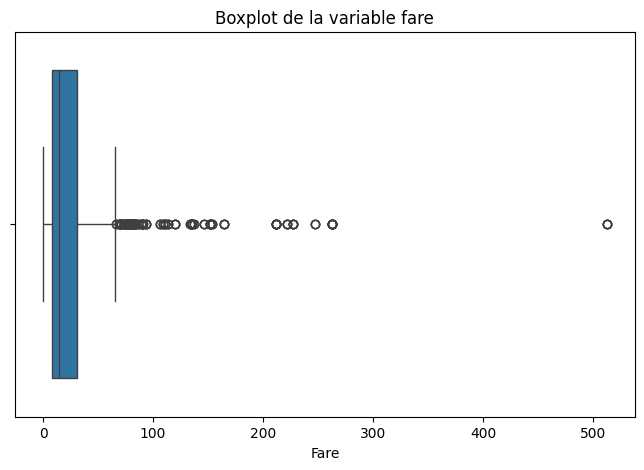

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_data['fare'])
plt.title("Boxplot de la variable fare")
plt.xlabel("Fare")
plt.show()

Le boxplot confirme la présence de valeurs aberrantes pour le tarif -> plusieurs passagers ont payé des prix très largement supérieurs à la médiane. Ces outliers devront être traités avant la phase de modélisation (log-transformation).

---
## 6. Analyse de la variable cible : survived <a id='section-5'></a>

Il est essentiel de comprendre la distribution de la variable cible car un fort déséquilibre entre les classes peut fausser les résultats d'un modèle ce qui nécessiterais des ajustements.

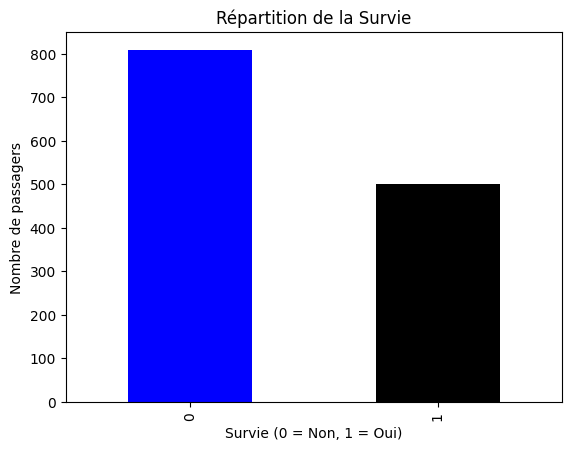

survived
0    0.618029
1    0.381971
Name: proportion, dtype: float64


In [8]:
# Visualisation 
plt.title("Répartition de la Survie")
df_data['survived'].value_counts().plot(kind='bar', color=['blue', 'black'])

plt.xlabel("Survie (0 = Non, 1 = Oui)")
plt.ylabel("Nombre de passagers")

plt.show()


# Analyse de la survie 
print(df_data['survived'].value_counts(normalize=True))

Le dataset est un peu déséquilibré : environ 62% de non-survivants contre 38% de survivants. Ce déséquilibre est modéré mais il sera néanmoins important d'en tenir compte lors de la phase de modélisation.

---
## 7. Distribution du port d'embarquement <a id='section-6'></a>

La variable embarked indique le port d'embarquement. On souhaite connaître sa distribution pour anticiper un éventuel encodage et vérifier si il pourrait être lié à la survie.

In [9]:
# Compter les occurrences de chaque classe
churn_counts = df_data["embarked"].value_counts()

# Afficher les résultats
print(churn_counts)

embarked
S    916
C    270
Q    123
Name: count, dtype: int64


La répartition des passagers selon le port d’embarquement montre que la plupart venaient de S, mais ce facteur ne semble pas influencer la survie, et apparaît donc comme peu informatif.

On obtient trois types distincts :
- Les **variables discrètes** (`pclass`, `sibsp`, `parch`,`survived`) prennent un petit nombre de valeurs entières.
- Les **variables continues** (`age`, `fare`) nécessiteront une analyse de distribution et potentiellement une transformation.
- Les **variables catégorielles** (`sex`, `embarked`, `cabin`, `name`, `ticket`) devront être encodées avant d'être intégrées à un modèle.
- **`survived`** est une variable binaire, mise, à part, car c'est le caractère etudié de ce travail.

---
## 8. Distribution des variables continues <a id='section-8'></a>

Les histogrammes permettent de visualiser la forme de la distribution des variables continues. On cherche notamment à identifier des asymétries (skewness) qui pourraient nécessiter une transformation (logarithmique ou Yeo-Johnson) avant la modélisation.

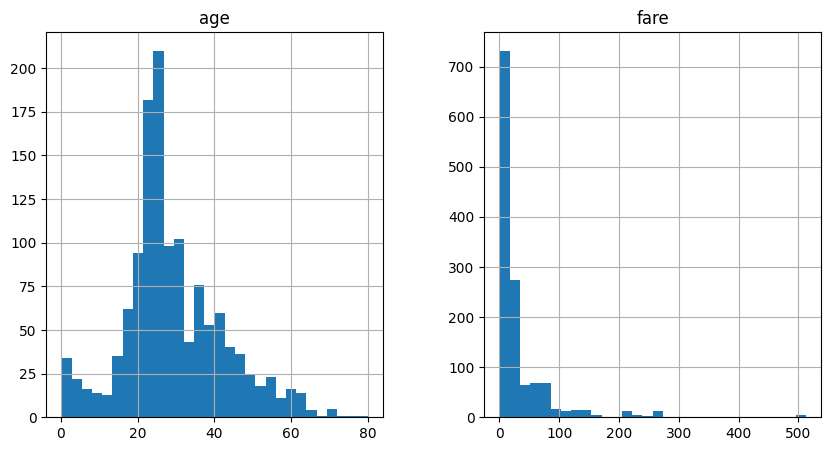

In [10]:
vars = identify_variable_types_verbose(df_data, False)


df_data[vars["cont_vars"]].hist(bins=30, figsize=(10, 5))
plt.show()

- **age** : la distribution est  symétrique, avec une légère asymétrie et une concentration entre 20 et 30 ans.
- **fare** : la distribution est fortement asymétrique, la plupart des passagers ont payé un tarif peu cher, mais quelques valeurs extrêmes tirent la moyenne vers le haut. Une transformation sera probablement nécessaire.

---
## 9. Matrice de corrélation <a id='section-9'></a>

La matrice de corrélation permet de mesurer les relations linéaires entre les variables numériques. Elle aide à identifier les variables les plus corrélées avec la cible (`survived`), et à détecter la **multicolinéarité** entre variables explicatives, qui peut nuire à certains modèles.

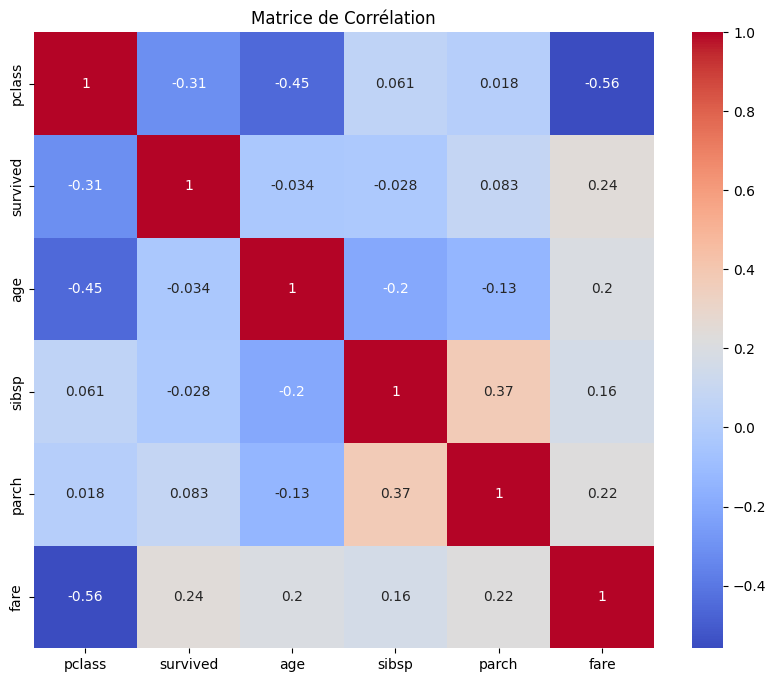

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_data[vars["num_vars"]].corr(), annot=True, cmap='coolwarm')
plt.title("Matrice de Corrélation")
plt.show()

- **pclass** est la variable la plus corrélée (négativement) avec **survived**.
- **fare** est positivement corrélée avec **survived**.
- **fare** et **pclass** sont fortement corrélées entre elles (multicolinéarité), ce qui signifie qu'il faudra peut-être choisir l'une ou l'autre lors de la modélisation.

---
## 11. Taux de survie selon le titre social <a id='section-11'></a>

Le titre social (Mr, Mrs, Miss, Master…) peut être extrait directement depuis la colonne name. Il constitue une variable intéressante car il nous indique à la fois le sexe, un âge extrapoler et le statut social du passager 

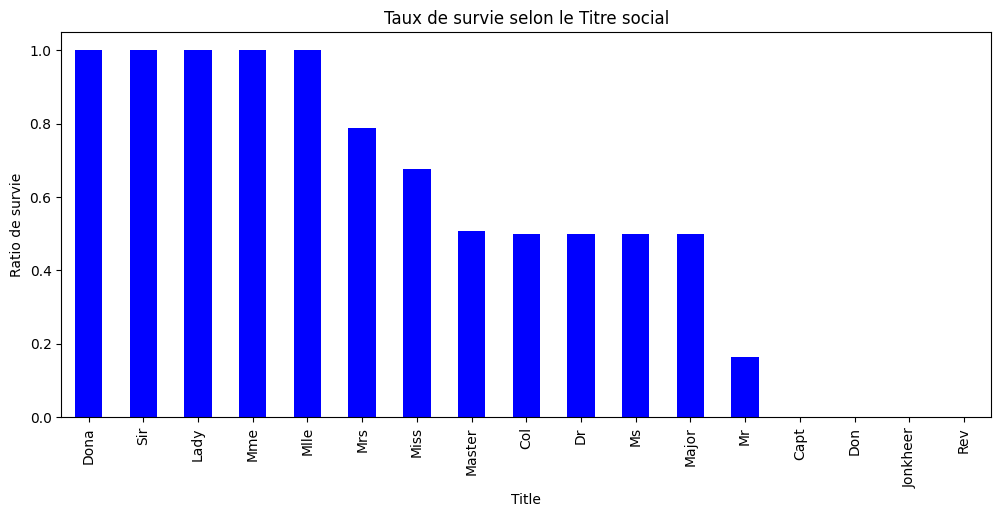

In [12]:
df_data['Title'] = df_data['name'].str.extract(', ([A-Za-z]+)\.', expand=False)

table_titles = pd.crosstab(df_data['Title'], df_data['survived'], normalize='index')
table_titles[1].sort_values(ascending=False).plot(kind='bar', figsize=(12,5), color='blue')

plt.title("Taux de survie selon le Titre social")
plt.ylabel("Ratio de survie")
plt.show()

Les titres féminins (**Mrs**, **Miss**) affichent un taux de survie nettement plus élevé,. Le titre **Master** (jeunes garçons) montre également un bon taux de survie. À l'inverse, **Mr** présente le taux le plus faible. Cette variable sera très utile en modélisation.

---
## 12. Taux de survie selon la classe de billet <a id='section-12'></a>

La classe de billet (pclass) est une variable ordinale (1 = 1ère classe, 2 = 2ème, 3 = 3ème). On compare le taux de survie entre les classes pour voir l'impact du statut économique sur les chances de survie.

Tableau croisé (effectifs) :
 survived    0    1
pclass            
1         123  200
2         158  119
3         528  181 

Tableau croisé (pourcentage) :
 survived          0          1
pclass                        
1         38.080495  61.919505
2         57.039711  42.960289
3         74.471086  25.528914 



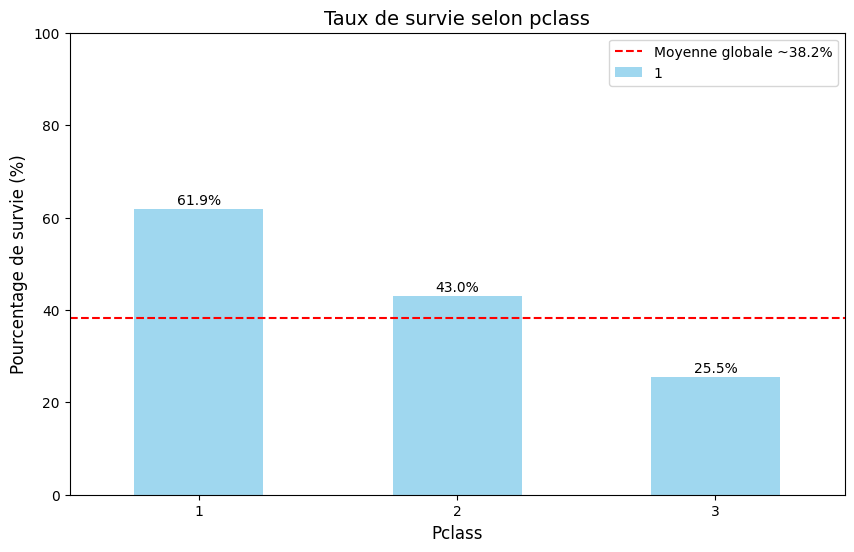

In [13]:
def plot_survival_by_class(df, feature='pclass', target='survived'):
    """
    Affiche le tableau croisé et le barplot du taux de survie par catégorie.
    
    Args:
        df (DataFrame) : Le jeu de données
        feature (str) : La variable explicative (ex: 'pclass')
        target (str) : La variable cible (ex: 'survived')
    """
    # Tableau croisé : effectifs
    table = pd.crosstab(df[feature], df[target])
    print("Tableau croisé (effectifs) :\n", table, "\n")
    
    # Tableau croisé : pourcentage
    table_pct = pd.crosstab(df[feature], df[target], normalize='index') * 100
    print("Tableau croisé (pourcentage) :\n", table_pct, "\n")
    
    # Barplot du taux de survie
    ax = table_pct[1].plot(kind='bar', figsize=(10,6), color='skyblue', alpha=0.8, rot=0)
    plt.axhline(y=df[target].mean()*100, color='red', linestyle='--', label=f"Moyenne globale ~{df[target].mean()*100:.1f}%")
    
    # Ajouter les valeurs sur chaque barre
    for i, v in enumerate(table_pct[1]):
        ax.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=10)
    
    plt.title(f"Taux de survie selon {feature}", fontsize=14)
    plt.xlabel(feature.capitalize(), fontsize=12)
    plt.ylabel("Pourcentage de survie (%)", fontsize=12)
    plt.legend()
    plt.ylim(0, 100)
    plt.show()

plot_survival_by_class(df_data)

Le lien entre classe et survie est **très flagrant** :
- **1ère classe** : environ 61.9% de survivants
- **2ème classe** : environ 43% de survivants.
- **3ème classe** : seulement environ 25.5% de survivants

La classe sociale constitue donc l'un des facteurs les plus déterminants dans la survie, ce que confirmait déjà la matrice de corrélation.

## 13. Reflexion originale <a id='section-13'></a>

Questionnement : Dans quelle mesure le titre social et le sexe combinés peuvent-ils prédire la survie par rapport à la seule classe du billet ? 

Creation d'une variable combiner et graphique pour visualiser

survived              0           1
Title_Sex                          
Don_male     100.000000    0.000000
Dona_female    0.000000  100.000000
Master_male   49.180328   50.819672
Miss_female   32.307692   67.692308
Mlle_female    0.000000  100.000000
Mme_female     0.000000  100.000000
Mr_male       83.751651   16.248349
Mrs_female    21.319797   78.680203
Ms_female     50.000000   50.000000
Rare_female    0.000000  100.000000
Rare_male     70.833333   29.166667


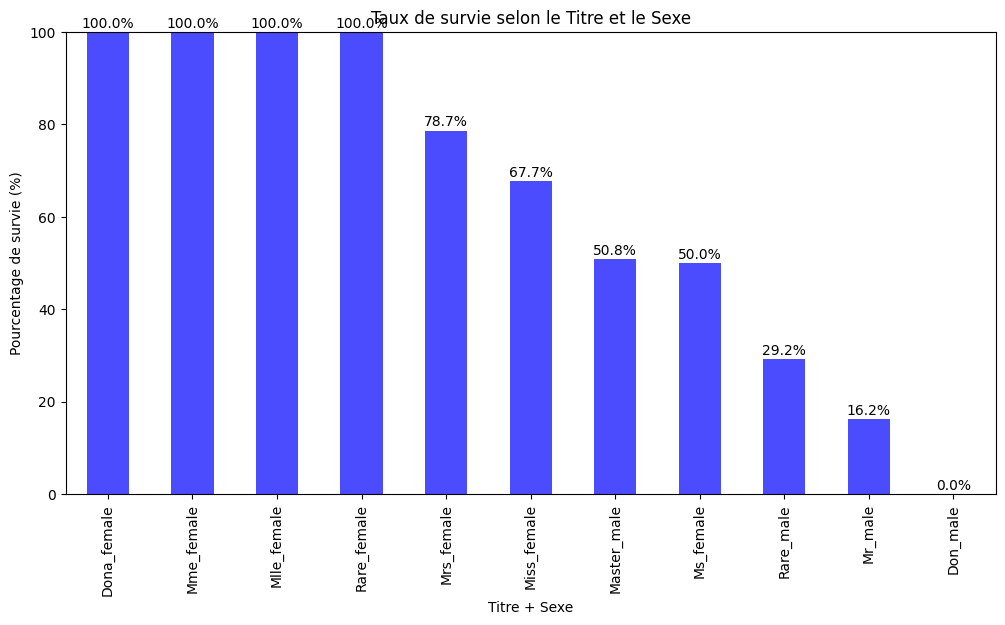

In [14]:
# Extraction des titres depuis la colonne 'name'
df_data['Title'] = df_data['name'].str.extract(', ([A-Za-z]+)\.', expand=False)

# Regrouper les titres rares pour éviter trop de catégories
rare_titles = ['Dr', 'Rev', 'Col', 'Major', 'Lady', 'Countess', 'Jonkheer', 'Sir', 'Capt']
df_data['Title'] = df_data['Title'].replace(rare_titles, 'Rare')

# Créer une variable combinée : titre + sexe
df_data['Title_Sex'] = df_data['Title'] + '_' + df_data['sex']

# Tableau croisé : taux de survie par Title_Sex
table = pd.crosstab(df_data['Title_Sex'], df_data['survived'], normalize='index') * 100
print(table)

# Barplot du taux de survie
ax = table[1].sort_values(ascending=False).plot(kind='bar', figsize=(12,6), color='blue', alpha=0.7)
plt.title("Taux de survie selon le Titre et le Sexe")
plt.ylabel("Pourcentage de survie (%)")
plt.xlabel("Titre + Sexe")
plt.ylim(0, 100)

# Afficher les valeurs sur les barres
for i, v in enumerate(table[1].sort_values(ascending=False)):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=10)

plt.show()

 L’analyse combinée du titre et du sexe montre que la survie dépend fortement de la position sociale et de l’âge perçu : les femmes et enfants, ainsi que certaines catégories sociales élevées, survivent plus souvent que les hommes adultes. Le titre social est donc une feature très informative pour prédire la survie.